# SMA Crossover Backtest

**pyportfolios.com tutorial T13** · QQQ + BTC-USD, Jan 2015 – Dec 2024 · vectorbt · Pandas · Pyfolio

The 50/200 moving-average crossover — the "golden cross" — is the systematic
trend-following workhorse: one rule, two parameters, centuries of folklore.
It is also the perfect vehicle for **backtesting discipline 101**. In this notebook we

1. build the long-or-flat crossover with **next-day execution** (no lookahead),
2. charge 10bp per side and compare against buy-and-hold on QQQ and BTC-USD,
3. sweep a 4×4 parameter grid to see how fragile the "edge" is per asset, and
4. stress the costs assumption (0 / 10 / 25bp).

The punchline: the *same rule* gets two different verdicts on two assets —
trend behaves differently per asset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import vectorbt as vbt

plt.rcParams["figure.figsize"] = (10, 5)

## 1 · Data: QQQ and BTC-USD closes

Ten years, two very different animals: the Nasdaq-100 ETF (exchange calendar,
~252 bars/year) and Bitcoin (trades every day, ~365 bars/year). BTC has prices
on weekends where QQQ has none, so we **dropna per column** and run each asset
on its own calendar — never forward-fill an exchange-traded asset over weekends
to match crypto, and never annualise both with the same 252.

In [2]:
raw = yf.download(["QQQ", "BTC-USD"], start="2015-01-01", end="2025-01-01",
                  auto_adjust=True, progress=False)["Close"]

qqq = raw["QQQ"].dropna()      # ~252 bars / year
btc = raw["BTC-USD"].dropna()  # ~365 bars / year
print(len(qqq), "QQQ bars ·", len(btc), "BTC bars")

2516 QQQ bars · 3653 BTC bars


## 2 · The rule — and the lookahead trap

Signal: long when the 50-day SMA is above the 200-day SMA, flat otherwise.

**The single most important line in this notebook is `shift(1)`.** The SMA
cross is computed on today's *close* — you cannot trade a close you have not
seen yet. Today's signal earns *tomorrow's* return. Skip the shift and you buy
every up-day one bar early: a lookahead bias that flatters almost any signal
and silently fabricates Sharpe. More backtests die of this one line than of
bad ideas.

We charge 10bp per side on every position change, and reserve the
first 250 bars of each asset for SMA warm-up so every parameter pair later
is judged on the *same* evaluation window.

In [3]:
FAST, SLOW, FEE, WARMUP = 50, 200, 0.001, 250

def backtest(px, fast=FAST, slow=SLOW, fee=FEE):
    signal   = (px.rolling(fast).mean() > px.rolling(slow).mean()).astype(float)
    position = signal.shift(1).fillna(0.0)   # <- no lookahead. The whole game.
    ret      = px.pct_change().fillna(0.0)
    cost     = position.diff().abs().fillna(0.0) * fee
    strat    = position * ret - cost
    return strat.iloc[WARMUP:], position.iloc[WARMUP:]

def stats(rets, ann):
    eq = (1 + rets).cumprod()
    sh = rets.mean() / rets.std(ddof=1) * np.sqrt(ann)
    return {"annRet": eq.iloc[-1] ** (ann / len(rets)) - 1,
            "annVol": rets.std(ddof=1) * np.sqrt(ann),
            "sharpe": sh,
            "maxDD": (eq / eq.cummax() - 1).min()}

## 3 · Equity curves vs buy-and-hold

Growth of $100 (log scale — BTC would render every other line invisible
otherwise). Watch *where* the strategy line detaches from buy-and-hold: it is
always in the big drawdowns. Trend following is not an accelerator; it is a
brake pedal.

QQQ      strat: Sharpe 0.97 maxDD -28.6% (5 trades, 82% in market)  |  b&h: Sharpe 0.90 maxDD -35.1%


BTC-USD  strat: Sharpe 1.28 maxDD -69.3% (9 trades, 64% in market)  |  b&h: Sharpe 1.27 maxDD -83.4%


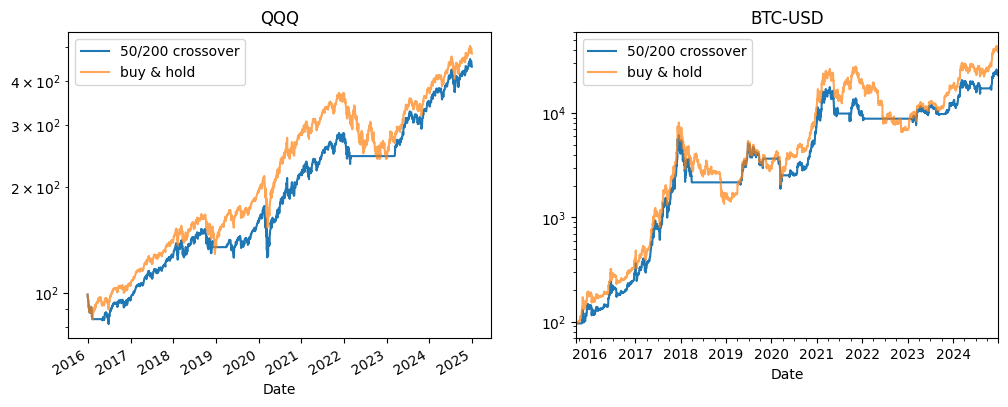

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, px, ann) in zip(axes, [("QQQ", qqq, 252), ("BTC-USD", btc, 365)]):
    strat, pos = backtest(px)
    bh = px.pct_change().fillna(0.0).iloc[WARMUP:]
    (100 * (1 + strat).cumprod()).plot(ax=ax, label="50/200 crossover")
    (100 * (1 + bh).cumprod()).plot(ax=ax, label="buy & hold", alpha=0.7)
    ax.set_yscale("log"); ax.set_title(name); ax.legend()

    s, b = stats(strat, ann), stats(bh, ann)
    n_tr = int((pos.diff() > 0).sum() + (pos.iloc[0] > 0))
    print(f"{name:8s} strat: Sharpe {s['sharpe']:.2f} maxDD {s['maxDD']:+.1%} "
          f"({n_tr} trades, {pos.mean():.0%} in market)  |  "
          f"b&h: Sharpe {b['sharpe']:.2f} maxDD {b['maxDD']:+.1%}")

Numbers to expect (deterministic — this is all closed historical data):

| | ann ret | Sharpe | maxDD | trades | time in mkt |
|---|---|---|---|---|---|
| QQQ 50/200 | 17.9% | 0.97 | -28.6% | 5 | 82% |
| QQQ buy-hold | 19.0% | 0.90 | -35.1% | — | 100% |
| BTC 50/200 | 79.3% | 1.28 | -69.3% | 9 | 64% |
| BTC buy-hold | 89.6% | 1.27 | -83.4% | — | 100% |

On QQQ the crossover roughly matches buy-and-hold's Sharpe while cutting the
max drawdown from -35% to -29%. On BTC it keeps pace
with a monster bull market while sidestepping the worst of the -83%
crashes. Neither is a money machine; both are drawdown insurance.

## 4 · Cross-check the fills with vectorbt

Any hand-rolled backtest loop deserves an independent referee. We rebuild the
same trades with `vectorbt`'s `Portfolio.from_signals` — same entry/exit bars,
same fees — and require the final value, max drawdown and trade count to
match. (We keep the *stats* in pandas: vectorbt's Sharpe annualises with its
own year convention, and we want explicit 252 vs 365 per asset.)

In [5]:
for name, px in [("QQQ", qqq), ("BTC-USD", btc)]:
    sig  = px.rolling(FAST).mean() > px.rolling(SLOW).mean()
    prev = sig.shift(1).fillna(False)
    entries = (sig & ~prev).iloc[WARMUP:].copy()
    exits   = (~sig & prev).iloc[WARMUP:].copy()
    if bool(sig.iloc[WARMUP - 1]):
        entries.iloc[0] = True   # carry the already-open position into the window
    pf = vbt.Portfolio.from_signals(px.iloc[WARMUP:], entries, exits,
                                    fees=FEE, init_cash=100, freq="1D")
    print(f"{name:8s} vectorbt: final ${pf.final_value():,.0f}  "
          f"maxDD {pf.max_drawdown():+.1%}  trades {pf.trades.count()}")

QQQ      vectorbt: final $443  maxDD -28.6%  trades 5
BTC-USD  vectorbt: final $22,720  maxDD -69.3%  trades 9


And a second referee for the *stats*: pyfolio's `perf_stats` on the QQQ
strategy returns. pyfolio hard-codes a 252-day year, so it is only valid for
the exchange-calendar asset — for BTC's 365-day calendar, keep the explicit
pandas stats above.

In [6]:
from pyfolio import timeseries

strat_q, _ = backtest(qqq)
timeseries.perf_stats(strat_q).loc[["Annual return", "Annual volatility",
                                    "Sharpe ratio", "Max drawdown"]]

C:\Python311\Lib\site-packages\pyfolio\pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


Annual return        0.178810
Annual volatility    0.188842
Sharpe ratio         0.966280
Max drawdown        -0.285594
dtype: float64

## 5 · Discipline 101: the parameter grid

One backtest is an anecdote. Before believing 50/200, ask: *does the
neighbourhood agree?* We sweep fast ∈ {10, 20, 50, 100} ×
slow ∈ {100, 150, 200, 250} and heat-map the Sharpe of each pair —
15 valid systems per asset, all with identical execution and costs.

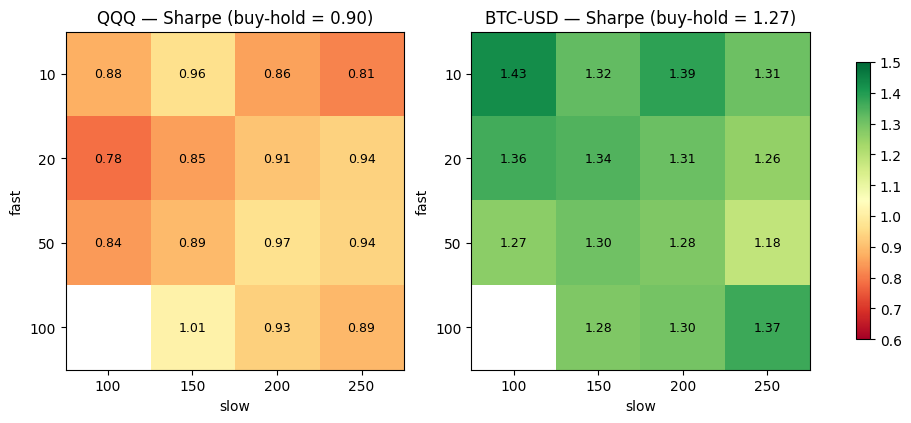

In [7]:
FASTS, SLOWS = [10, 20, 50, 100], [100, 150, 200, 250]

def sharpe_grid(px, ann):
    g = np.full((len(FASTS), len(SLOWS)), np.nan)
    for i, f in enumerate(FASTS):
        for j, s in enumerate(SLOWS):
            if f >= s:
                continue
            rets, _ = backtest(px, f, s)
            g[i, j] = rets.mean() / rets.std(ddof=1) * np.sqrt(ann)
    return g

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, px, ann) in zip(axes, [("QQQ", qqq, 252), ("BTC-USD", btc, 365)]):
    g = sharpe_grid(px, ann)
    bh = px.pct_change().fillna(0.0).iloc[WARMUP:]
    bh_sh = bh.mean() / bh.std(ddof=1) * np.sqrt(ann)
    im = ax.imshow(g, cmap="RdYlGn", vmin=0.6, vmax=1.5)
    for i in range(len(FASTS)):
        for j in range(len(SLOWS)):
            if not np.isnan(g[i, j]):
                ax.text(j, i, f"{g[i, j]:.2f}", ha="center", va="center", fontsize=9)
    ax.set_xticks(range(len(SLOWS)), SLOWS); ax.set_yticks(range(len(FASTS)), FASTS)
    ax.set_xlabel("slow"); ax.set_ylabel("fast")
    ax.set_title(f"{name} — Sharpe (buy-hold = {bh_sh:.2f})")
plt.colorbar(im, ax=axes, shrink=0.8);

Read the two grids side by side — this is the card's thesis in one picture:

- **QQQ**: every cell lands between 0.78 and 1.01,
  straddling buy-and-hold's 0.90. Only 7 of
  15 cells beat it, none decisively. Picking the best cell after
  the fact and calling it edge is selection bias, not alpha.
- **BTC**: 12 of 15 cells sit at or above
  buy-and-hold's 1.27, and *every* cell slashes the max drawdown.
  The trend signal genuinely earned its keep here — the asset trends harder and
  crashes harder.

Same rule, same decade, two verdicts. **Trend behaves differently per asset.**

## 6 · Costs sensitivity: 0 / 10 / 25 bp

The 50/200 pair trades a handful of times a decade, so costs barely dent it.
Speed the system up (10/100) and the cost line starts to matter. Slow trend
systems are cheap to run; fast ones must clear a real hurdle.

In [8]:
rows = []
for name, px, ann in [("QQQ", qqq, 252), ("BTC-USD", btc, 365)]:
    for f, s in [(50, 200), (10, 100)]:
        row = {"asset": name, "pair": f"{f}/{s}"}
        for bp in (0, 10, 25):
            rets, pos = backtest(px, f, s, fee=bp / 1e4)
            row[f"Sharpe@{bp}bp"] = round(rets.mean() / rets.std(ddof=1) * np.sqrt(ann), 2)
        row["trades"] = int((pos.diff() > 0).sum() + (pos.iloc[0] > 0))
        rows.append(row)
pd.DataFrame(rows).set_index(["asset", "pair"])

Sharpe@0bp  Sharpe@10bp  Sharpe@25bp  trades
asset   pair                                                
QQQ     50/200        0.97         0.97         0.96       5
        10/100        0.90         0.88         0.84      18
BTC-USD 50/200        1.29         1.28         1.28       9
        10/100        1.44         1.43         1.42      21

## 7 · The in-sample warning

Everything above is **one ten-year sample, evaluated in-sample**. There is no
walk-forward, no out-of-sample holdout, no deflation for the 15
variants we just eyeballed per asset. 2015–2024 contains two of the strongest
trend decades either asset has ever printed — a regime gift the next decade
owes nobody. Before promoting any cell of that grid, run the honesty checklist
from our cross-sectional momentum article: point-in-time data, walk-forward
splits, costs at the pessimistic end, and a multiple-testing haircut on the
best-looking Sharpe.

## Takeaways

- `signal.shift(1)` is non-negotiable: trade the close *after* the signal, never the close *inside* it.
- On QQQ the crossover is regime insurance — buy-and-hold's Sharpe, ~81% of its drawdown. On BTC it kept a 1.27-Sharpe bull market *and* cut the worst crash by a third.
- Judge the neighbourhood, not the cell: QQQ's grid says "no edge, decent brake"; BTC's says "the trend was real (in this sample)".
- Slow trend is nearly free to trade; fast trend pays a visible costs tax.
- One sample proves nothing. Walk-forward or it didn't happen.

*© pyportfolios.com — runnable companion to the article. Data: Yahoo Finance via yfinance.*